<a href="https://colab.research.google.com/github/emmex43/Machine-learning-fantasy/blob/main/AI_Powered_Chemical_Process_Optimization_%26_Safety_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset preview:
   Temperature   Pressure   Flow_Rate  Hazard
0   154.967142  56.996777  186.496435       0
1   148.617357  54.623168  197.109627       0
2   156.476885  50.298152  184.151602       0
3   165.230299  46.765316  193.840769       0
4   147.658466  53.491117  162.127707       0

Statistics:
       Temperature     Pressure    Flow_Rate      Hazard
count  1000.000000  1000.000000  1000.000000  1000.00000
mean    150.997268    50.890335   200.116684     0.06100
std      11.097555     5.967700    19.669086     0.23945
min     117.587327    35.298057   139.609757     0.00000
25%     143.847336    47.166947   187.040008     0.00000
50%     150.483033    50.523942   199.994985     0.00000
75%     157.119608    53.978420   213.218306     0.00000
max     206.140946    76.590510   278.524754     1.00000

Hazard Rate: 0.061


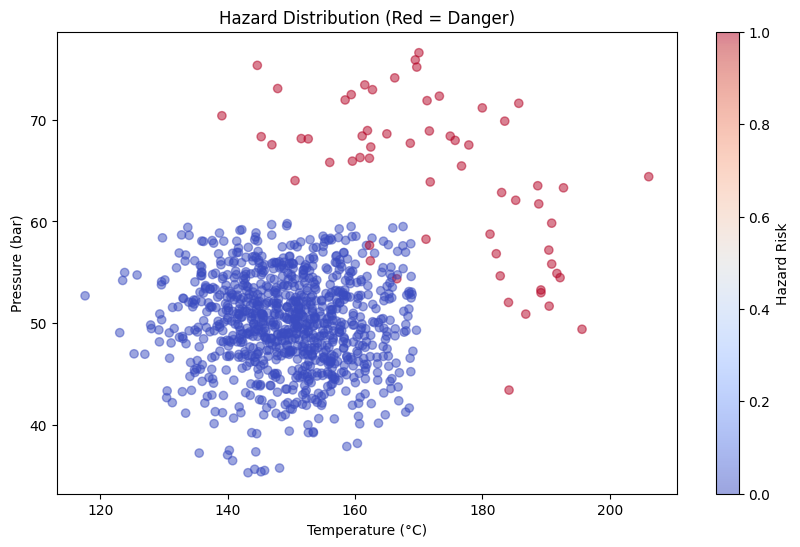

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install required libraries (if not already installed)
!pip install pandas numpy matplotlib

# Generate synthetic chemical plant data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate 1000 samples
np.random.seed(42)  # For reproducibility
n_samples = 1000

# Base values (normal operation)
data = {
    "Temperature": np.random.normal(150, 10, n_samples),  # Mean=150°C, SD=10
    "Pressure": np.random.normal(50, 5, n_samples),       # Mean=50 bar, SD=5
    "Flow_Rate": np.random.normal(200, 20, n_samples),    # Mean=200 L/min, SD=20
}

# Simulate hazards (5% of data)
hazard_conditions = (
    (data["Temperature"] > 170) |
    (data["Pressure"] > 60) |
    (data["Flow_Rate"] < 150)
)
data["Hazard"] = np.where(hazard_conditions, 1, 0)

# Add noise to hazard cases
for i in range(n_samples):
    if data["Hazard"][i] == 1:
        data["Temperature"][i] += np.random.uniform(5, 20)  # Overheating
        data["Pressure"][i] += np.random.uniform(3, 15)     # Pressure spike

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV (in Colab's temporary storage)
df.to_csv("chemical_plant_data.csv", index=False)

# Validate data
print("Dataset preview:")
print(df.head())
print("\nStatistics:")
print(df.describe())
print("\nHazard Rate:", df["Hazard"].mean())

# Visualize hazards
plt.figure(figsize=(10, 6))
plt.scatter(df["Temperature"], df["Pressure"], c=df["Hazard"], alpha=0.5, cmap="coolwarm")
plt.xlabel("Temperature (°C)"); plt.ylabel("Pressure (bar)")
plt.title("Hazard Distribution (Red = Danger)")
plt.colorbar(label="Hazard Risk")
plt.show()

# Download the CSV to your local machine (optional)
from google.colab import files
files.download("chemical_plant_data.csv")

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load your generated data
df = pd.read_csv("chemical_plant_data.csv")

# --- Model 1: Hazard Detection ---
X_hazard = df[["Temperature", "Pressure", "Flow_Rate"]]
y_hazard = df["Hazard"]
X_train, X_test, y_train, y_test = train_test_split(X_hazard, y_hazard, test_size=0.2)

hazard_model = RandomForestClassifier()
hazard_model.fit(X_train, y_train)
print(f"Hazard Model Accuracy: {hazard_model.score(X_test, y_test):.2f}")

# --- Model 2: Process Optimization ---
# Target: Maximize Flow_Rate while keeping Temp < 165 and Pressure < 55
df_safe = df[(df["Temperature"] < 165) & (df["Pressure"] < 55)]  # Filter safe conditions
X_opt = df_safe[["Temperature", "Pressure"]]
y_opt = df_safe["Flow_Rate"]  # We'll predict optimal flow rate

opt_model = RandomForestRegressor()
opt_model.fit(X_opt, y_opt)
print(f"Optimization Model R² Score: {opt_model.score(X_opt, y_opt):.2f}")

# Save models (for Streamlit)
import joblib
joblib.dump(hazard_model, "hazard_model.pkl")
joblib.dump(opt_model, "opt_model.pkl")

Hazard Model Accuracy: 1.00
Optimization Model R² Score: 0.83


['opt_model.pkl']